# 03 Effect Estimation Review

Review-only notebook for the saved main observational effect-estimation artifacts. Run `make run-estimation` before executing these cells.

In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
processed_dir = PROJECT_ROOT / "data" / "processed"
figures_dir = PROJECT_ROOT / "reports" / "figures"
docs_dir = PROJECT_ROOT / "docs"

effect_path = processed_dir / "effect_estimates_main.csv"
balance_path = processed_dir / "balance_table_main.csv"
metadata_path = processed_dir / "estimation_run_metadata.json"
overlap_plot_path = figures_dir / "overlap_plot.png"
love_plot_path = figures_dir / "love_plot_main.png"
summary_path = docs_dir / "estimation_summary.md"

for path in [effect_path, balance_path, metadata_path, overlap_plot_path, love_plot_path, summary_path]:
    if not path.exists():
        raise FileNotFoundError(f"Missing estimation artifact: {path}")

## Effect Estimates

In [2]:
effect_estimates = pd.read_csv(effect_path)
effect_estimates

,estimator,preferred,estimand,status,estimate,treated_mean,control_mean,std_error,ci_lower,ci_upper,uncertainty_method,n,matched_pairs,matched_retention,notes
0,regression_adjustment,False,ATE risk difference,success,0.234926,0.663548,0.428623,0.000392,0.234157,0.235694,empirical predicted-contrast score,28128.0,NaN,NaN,mean predicted potential outcome under separat...
1,stabilized_iptw,False,ATE risk difference,success,0.233985,0.662309,0.428325,0.008905,0.216530,0.251439,empirical stabilized-IPTW contrast score,28128.0,NaN,NaN,stabilized IPTW Hajek-style weighted mean cont...
2,aipw,True,ATE risk difference,success,0.235260,0.664047,0.428788,0.005720,0.224048,0.246471,empirical AIPW score,28128.0,NaN,NaN,doubly robust AIPW estimator using propensity ...
3,nearest_neighbor_matching,False,ATT-style matched risk difference for treated ...,skipped,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,poor overlap diagnostics; matching estimate no...


## Diagnostics Metadata

In [3]:
metadata = json.loads(metadata_path.read_text())
display(pd.Series(metadata["analysis"]).drop(labels=["treatment"], errors="ignore"))
display(pd.Series(metadata["diagnostics"]).drop(labels=["propensity_summary", "stabilized_weight_summary", "common_support"], errors="ignore"))
display(pd.DataFrame(metadata["diagnostics"]["propensity_summary"]).T)
display(pd.Series(metadata.get("warnings", []), name="warnings"))

cohort_rows                             28128
analysis_rows                           28128
excluded_unavailable_or_missing_rows        0
treated_count                           14134
control_count                           13994
outcome_success_count                   15385
dtype: int64

effective_sample_size                              26694.299162
propensity_clip_epsilon                                   0.001
propensity_scores_clipped_for_computation_count               5
poor_overlap_by_propensity                                 True
poor_overlap_by_common_support                            False
max_abs_smd_after_weighting                             0.02234
poor_balance_after_weighting                              False
poor_overlap                                               True
dtype: object

,min,p01,p05,mean,median,p95,p99,max
all,0.000240,0.212663,0.337783,0.502451,0.499084,0.655175,0.710828,0.853557
treated,0.061996,0.259687,0.375373,0.521381,0.515219,0.668348,0.720803,0.853557
control,0.000240,0.178096,0.310584,0.483331,0.484896,0.636444,0.692611,0.842990


0    Overlap or post-weighting balance diagnostics ...
1    Some propensity scores were clipped only for f...
2    Nearest-neighbor matching skipped: poor overla...
Name: warnings, dtype: str

## Balance Table

In [4]:
balance = pd.read_csv(balance_path)
balance.head(30)

,variable,smd_unweighted,smd_weighted,abs_smd_unweighted,abs_smd_weighted,improved_after_weighting
0,cat__baseline_age_band_0-35,-0.219564,-0.000103,0.219564,0.000103,True
1,num__baseline_num_of_prev_attempts,-0.216448,0.021332,0.216448,0.021332,True
2,cat__baseline_age_band_35-55,0.208855,-0.000060,0.208855,0.000060,True
3,num__baseline_registered_before_start,0.110708,-0.000298,0.110708,0.000298,True
4,cat__baseline_imd_band_<MISSING>,0.098462,-0.003655,0.098462,0.003655,True
5,num__baseline_studied_credits,-0.088997,0.003055,0.088997,0.003055,True
6,cat__baseline_gender_M,-0.084455,-0.000260,0.084455,0.000260,True
7,cat__baseline_gender_F,0.084455,0.000260,0.084455,0.000260,True
8,cat__baseline_imd_band_0-10%,-0.080613,0.002844,0.080613,0.002844,True
9,num__baseline_date_registration,-0.080222,-0.000793,0.080222,0.000793,True


## Figures

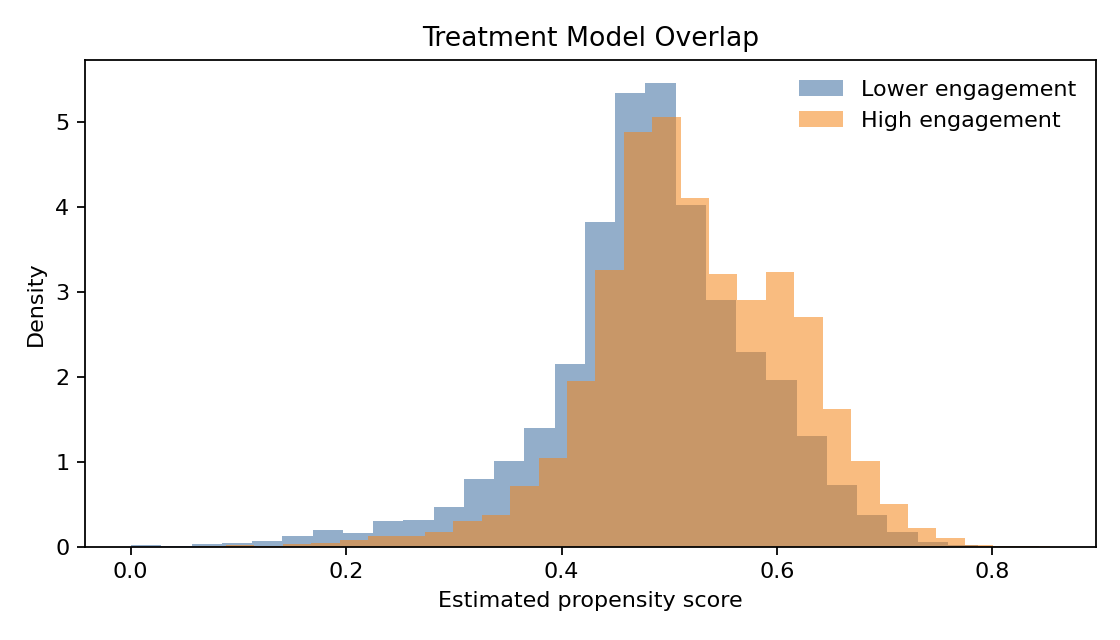

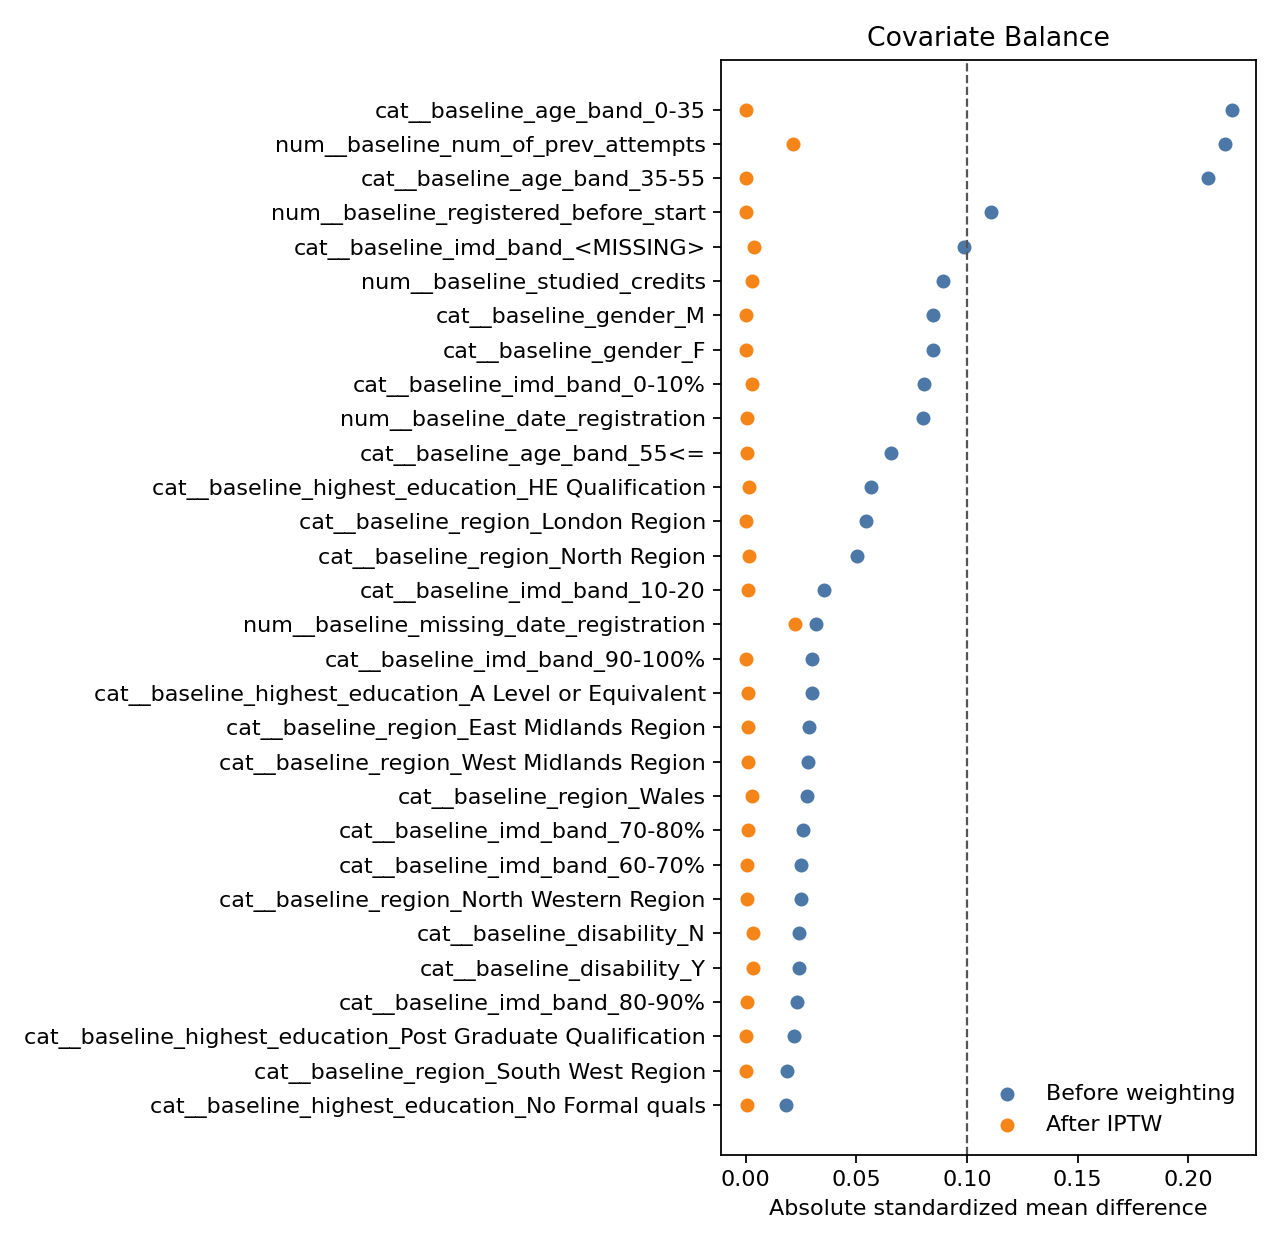

In [5]:
display(Image(filename=str(overlap_plot_path)))
display(Image(filename=str(love_plot_path)))

## Generated Summary

In [6]:
display(Markdown(summary_path.read_text()))

# Estimation Summary

This summary is generated from the saved estimation artifacts. It should not be edited to hardcode conclusions.

## Main Estimand

- Estimand: population average treatment effect risk difference.
- Treatment: `treatment_high_engagement_14d_median`.
- Outcome: `outcome_success`.
- Adjustment set source: `oulad_causal.dag.recommended_baseline_adjustment_set`.
- Analysis rows: 28128.

## Main Estimators

| estimator | preferred | status | estimate | 95% CI | SE | notes |
| --- | --- | --- | ---: | ---: | ---: | --- |
| regression_adjustment | False | success | 0.234926 | [0.234157, 0.235694] | 0.000392 | mean predicted potential outcome under separate logistic outcome regressions |
| stabilized_iptw | False | success | 0.233985 | [0.216530, 0.251439] | 0.008905 | stabilized IPTW Hajek-style weighted mean contrast; no default truncation |
| aipw | True | success | 0.235260 | [0.224048, 0.246471] | 0.005720 | doubly robust AIPW estimator using propensity and separate outcome nuisance models |
| nearest_neighbor_matching | False | skipped |  |  |  | poor overlap diagnostics; matching estimate not reported |

Preferred main estimate: `aipw` with risk difference 0.235260.

## Diagnostics Produced

- Effect estimates table: `data/processed/effect_estimates_main.csv`.
- Balance table: `data/processed/balance_table_main.csv`.
- Overlap plot: `reports/figures/overlap_plot.png`.
- Love plot: `reports/figures/love_plot_main.png`.
- Effective sample size after stabilized weighting: 26694.30.
- Propensity score range: 0.000240 to 0.853557.
- Propensity scores clipped for finite arithmetic: 5.
- Common support outside share: 0.000498.
- Maximum absolute SMD after weighting: 0.022340.
- Poor overlap flag: True.

## Known Limitations

- This is an observational estimate and relies on conditional exchangeability after the documented baseline adjustment set.
- Motivation, time availability, outside support, employment, and competing obligations remain unmeasured.
- VLE clicks measure platform interaction quantity, not necessarily learning quality.
- Stabilized weights are not truncated by default; poor overlap is detected and reported instead.
- Later assessment behavior and later VLE activity are intentionally excluded from the primary adjustment set because they may be post-treatment mediators.

## Automatic Warnings

- Overlap or post-weighting balance diagnostics were flagged as poor.
- Some propensity scores were clipped only for finite arithmetic; weights were not otherwise truncated.
- Nearest-neighbor matching skipped: poor overlap diagnostics; matching estimate not reported.
